# Caso de estudio

## Una pregunta real

Supongamos que queremos evaluar el comportamiento del recurso solar en una ubicación.

Mi jefe me pregunta:

- ¿Cuál fue el peor mes para la generación solar?
- ¿Cuál fue el mejor mes?
- ¿Qué tan estable es el recurso a lo largo del tiempo?

Disponemos de aproximadamente 10 años de información horaria.

¿Cómo podemos responder estas preguntas utilizando Python?


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

# Paso 1. Obtener datos

Muchas veces los datos no están en nuestro computador.

Hoy existen fuentes abiertas que permiten acceder a información energética y meteorológica desde cualquier lugar del mundo.

En este ejemplo utilizaremos la API de NASA POWER para descargar información de irradiancia solar.

In [2]:
# Coordenadas de Bogotá

lat = 4.7110
lon = -74.0721

# Año de prueba

year = 2022

# Paso 2. Conectarnos a una API

Una API permite que programas diferentes intercambien información.

Python puede solicitar automáticamente los datos que necesitamos.

In [3]:
url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    "?parameters=ALLSKY_SFC_SW_DWN"
    "&community=RE"
    f"&longitude={lon}"
    f"&latitude={lat}"
    f"&start={year}0101"
    f"&end={year}1231"
    "&format=JSON"
)

print(url)

https://power.larc.nasa.gov/api/temporal/hourly/point?parameters=ALLSKY_SFC_SW_DWN&community=RE&longitude=-74.0721&latitude=4.711&start=20220101&end=20221231&format=JSON


In [4]:
response = requests.get(url)

print(f"Estado de la consulta: {response.status_code}")

Estado de la consulta: 200


# Paso 3. Explorar la información descargada

La respuesta de la API contiene miles de observaciones.

Ahora convertiremos esos datos en una tabla que podamos analizar fácilmente.

In [6]:
data = response.json()

list(data["properties"]["parameter"].keys())

['ALLSKY_SFC_SW_DWN']

In [8]:
ghi = data["properties"]["parameter"]["ALLSKY_SFC_SW_DWN"]

df_2022 = pd.DataFrame(
    ghi.items(),
    columns=["datetime", "GHI"]
)

df_2022

,datetime,GHI
0,2022010100,0.0
1,2022010101,0.0
2,2022010102,0.0
3,2022010103,0.0
4,2022010104,0.0
...,...,...
8755,2022123119,0.0
8756,2022123120,0.0
8757,2022123121,0.0
8758,2022123122,0.0


In [9]:
df_2022["datetime"] = pd.to_datetime(
    df_2022["datetime"],
    format="%Y%m%d%H"
)

df_2022.head()

,datetime,GHI
0,2022-01-01 00:00:00,0.0
1,2022-01-01 01:00:00,0.0
2,2022-01-01 02:00:00,0.0
3,2022-01-01 03:00:00,0.0
4,2022-01-01 04:00:00,0.0


In [ ]:
print("Registros descargados:")

df_2022.shape

# Paso 4. Descargar 10 años de información

La pregunta que queremos responder no se basa en unos pocos datos.

Queremos analizar aproximadamente 10 años de irradiancia horaria.

Python puede conectarse directamente a la API de NASA POWER y descargar toda la información necesaria.

In [11]:
lat = 4.7110
lon = -74.0721

start_year = 2014
end_year = 2023

In [12]:
url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    "?parameters=ALLSKY_SFC_SW_DWN"
    "&community=RE"
    f"&longitude={lon}"
    f"&latitude={lat}"
    f"&start={start_year}0101"
    f"&end={end_year}1231"
    "&format=JSON"
)

url

'https://power.larc.nasa.gov/api/temporal/hourly/point?parameters=ALLSKY_SFC_SW_DWN&community=RE&longitude=-74.0721&latitude=4.711&start=20140101&end=20231231&format=JSON'

In [13]:
response = requests.get(url)

print(f"Estado de la consulta: {response.status_code}")

Estado de la consulta: 200


# Paso 5. Convertir la respuesta en una tabla

La API devuelve información en formato JSON.

Transformaremos esa información en un DataFrame para facilitar el análisis.

In [15]:
# Convertir la respuesta JSON de la API en un DataFrame

df = pd.DataFrame(
    response.json()["properties"]["parameter"]["ALLSKY_SFC_SW_DWN"].items(),
    columns=["datetime", "GHI"]
)

# Convertir la fecha a formato datetime

df["datetime"] = pd.to_datetime(
    df["datetime"],
    format="%Y%m%d%H"
)

df

,datetime,GHI
0,2014-01-01 00:00:00,0.0
1,2014-01-01 01:00:00,0.0
2,2014-01-01 02:00:00,0.0
3,2014-01-01 03:00:00,0.0
4,2014-01-01 04:00:00,0.0
...,...,...
87643,2023-12-31 19:00:00,0.0
87644,2023-12-31 20:00:00,0.0
87645,2023-12-31 21:00:00,0.0
87646,2023-12-31 22:00:00,0.0


In [ ]:
df.shape

# Paso 6. Responder la pregunta de negocio

Ya tenemos los datos.

Ahora vamos a responder la pregunta que planteó el gerente:

¿Cuál fue el peor mes para la generación solar?


In [16]:
df["month"] = df["datetime"].dt.month

df["year"] = df["datetime"].dt.year

df.head()

,datetime,GHI,month,year
0,2014-01-01 00:00:00,0.0,1,2014
1,2014-01-01 01:00:00,0.0,1,2014
2,2014-01-01 02:00:00,0.0,1,2014
3,2014-01-01 03:00:00,0.0,1,2014
4,2014-01-01 04:00:00,0.0,1,2014


In [17]:
ghi_mensual = (
    df
    .groupby("month")["GHI"]
    .mean()
)

ghi_mensual

month
1     203.702413
2     200.067086
3     184.463942
4     186.539917
5     188.970624
6     186.865062
7     191.686082
8     199.276152
9     207.788536
10    198.630159
11    188.115600
12    198.356427
Name: GHI, dtype: float64

### ¿Cuál creen que será el peor mes?

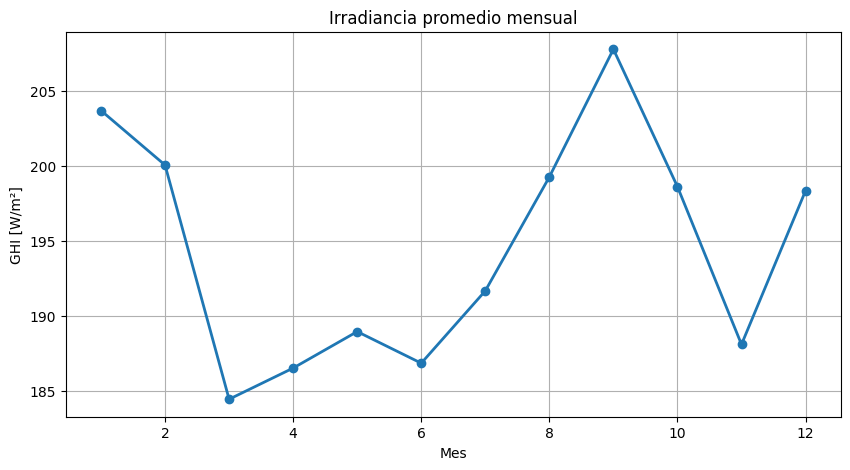

In [18]:
plt.figure(figsize=(10,5))

ghi_mensual.plot(
    marker="o",
    linewidth=2
)

plt.title(
    "Irradiancia promedio mensual"
)

plt.ylabel("GHI [W/m²]")
plt.xlabel("Mes")
plt.grid(True)

plt.show()

In [19]:
peor_mes = ghi_mensual.idxmin()
mejor_mes = ghi_mensual.idxmax()

print(
    f"Peor mes: {peor_mes}"
)

print(
    f"Mejor mes: {mejor_mes}"
)

Peor mes: 3
Mejor mes: 9


# Reflexión

Observe que Python no generó valor por sí solo.

El valor apareció cuando transformamos:

87600 registros

↓

Información útil

↓

Una respuesta concreta para apoyar la toma de decisiones.

Ese es exactamente el objetivo de este curso.

# Paso 7. Utilizando Inteligencia Artificial para profundizar el análisis

Hasta ahora respondimos una pregunta específica:

**¿Cuál fue el peor mes para la generación solar?**

Sin embargo, en un entorno profesional normalmente queremos responder preguntas más complejas.

Por ejemplo:

- ¿Existen tendencias en el recurso solar a lo largo de los años?
- ¿Qué meses presentan mayor variabilidad?
- ¿Se observan patrones estacionales?
- ¿Existen años atípicos?
- ¿Qué implicaciones tendría esto para un proyecto fotovoltaico?

En lugar de escribir todo el código manualmente, podemos apoyarnos en herramientas de Inteligencia Artificial como GitHub Copilot.

## Prompt para GitHub Copilot

Tengo un DataFrame llamado `df` que contiene:

- `datetime`: fecha y hora de la medición
- `GHI`: irradiancia horizontal global

El conjunto de datos contiene aproximadamente 10 años de información horaria.

Quiero realizar un análisis exploratorio completo que incluya:

1. Estadísticas descriptivas.
2. Irradiancia promedio por mes.
3. Irradiancia promedio por año.
4. Boxplots mensuales para evaluar variabilidad.
5. Identificación del mejor y peor año.
6. Identificación del mejor y peor mes.
7. Tendencia temporal del recurso solar.
8. Comentarios y títulos claros en el código.
9. Gráficas profesionales utilizando Matplotlib o Seaborn.

Genera el código Python completo y bien documentado.

In [ ]:
# Pegar aquí la respuesta generada por GitHub Copilot